# Underwater Image Quality Assessment
## Version 5 | Multi-Stage Concatenation Fusion | Swin-Base
### SAUD Dataset | Kaggle

---

**Architecture:**
```
Input Image (224x224x3)
        |
Swin-Base Backbone
  Patch Embed  [FROZEN]
  Stage 1      [FROZEN]
  Stage 2      [TRAINABLE] -> GAP -> f2 (256-dim)
  Stage 3      [TRAINABLE] -> GAP -> f3 (512-dim)
  Stage 4      [TRAINABLE] -> GAP -> f4 (1024-dim)
        |
  Concatenate [f2 || f3 || f4] = 1792-dim
        |
  Regression MLP
  Linear(1792 -> 512) -> BN -> GELU -> Dropout(0.4)
  Linear(512  -> 128) -> BN -> GELU -> Dropout(0.3)
  Linear(128  -> 1)   -> Sigmoid
        |
  Quality Score [0,1] * 100 = MOS
```

**Loss:**
```
L = 0.2*L1 + 0.2*MSE + 0.4*(1-PLCC) + 0.2*RankLoss
```
PLCC weight is highest because target is PLCC 85-90.

**Key design decisions:**
- Only patch embed and Stage 1 are frozen. Stages 2, 3, 4 are all trainable.
- Features from Stages 2, 3, 4 are concatenated to capture multi-scale information.
- Stage 1 features are skipped as they are too low-level (edges, basic colors).
- Batch normalization in MLP stabilizes training with high-dimensional fused input.
- PLCC loss weight set to 0.4 to directly push correlation higher.

## Cell 1 - GPU Check

In [43]:
import torch

print('GPU Check')
print('='*40)
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'PyTorch: {torch.__version__}')
else:
    print('No GPU found.')
    print('Fix: Session Options -> Accelerator -> GPU T4 x2')
print('='*40)

GPU Check
GPU    : Tesla T4
VRAM   : 15.6 GB
PyTorch: 2.9.0+cu126


## Cell 2 - Install Libraries

In [44]:
!pip install timm --quiet
!pip install scipy --quiet

import timm, scipy
print(f'timm  : {timm.__version__}')
print(f'scipy : {scipy.__version__}')

timm  : 1.0.24
scipy : 1.16.3


## Cell 3 - Dataset Paths

In [45]:
import os
import json

DATASET_ROOT = '/kaggle/input/datasets/divyanshrajput3/saud-dataset/SAUD_dataset/Enhanced'
JSON_PATH    = '/kaggle/input/datasets/divyanshrajput3/saud-dataset/SAUD_dataset/saud_dataset.json'

print(f'DATASET_ROOT : {DATASET_ROOT}')
if os.path.exists(DATASET_ROOT):
    img_exts  = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    img_count = sum(
        1 for r, d, fs in os.walk(DATASET_ROOT)
        for f in fs if f.lower().endswith(img_exts)
    )
    print(f'Found. Images: {img_count}')
else:
    print('NOT FOUND. Check DATASET_ROOT path.')

print(f'\nJSON_PATH : {JSON_PATH}')
if os.path.exists(JSON_PATH):
    with open(JSON_PATH) as f:
        data = json.load(f)
    scores = list(data.values())
    print(f'Found. Entries: {len(data)}')
    print(f'MOS range : [{min(scores):.0f}, {max(scores):.0f}]')
    print(f'MOS mean  : {sum(scores)/len(scores):.1f}')
    print('\nFirst 4 sample checks:')
    for k, v in list(data.items())[:4]:
        full   = os.path.join(DATASET_ROOT, k)
        status = 'OK' if os.path.exists(full) else 'MISSING'
        print(f'  [{status}] {k} -> MOS={v}')
else:
    print('NOT FOUND. Check JSON_PATH.')

DATASET_ROOT : /kaggle/input/datasets/divyanshrajput3/saud-dataset/SAUD_dataset/Enhanced
Found. Images: 1023

JSON_PATH : /kaggle/input/datasets/divyanshrajput3/saud-dataset/SAUD_dataset/saud_dataset.json
Found. Entries: 1000
MOS range : [0, 88]
MOS mean  : 45.0

First 4 sample checks:
  [OK] group_1/1/1_BL-TM.png -> MOS=52
  [OK] group_1/1/1_GL-net.png -> MOS=82
  [OK] group_1/1/1_histogram prior.png -> MOS=18
  [OK] group_1/1/1_RayleighDistribution.png -> MOS=8


## Cell 4 - Imports and Config

In [46]:
import os
import json
import random
import copy
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from scipy.stats import spearmanr, pearsonr, kendalltau
import timm

warnings.filterwarnings('ignore')

# --- Hyperparameters ---
SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 8
EPOCHS        = 50
PATIENCE      = 10
WARMUP_EPOCHS = 5
TTA_RUNS      = 5

# Differential learning rates.
# Trainable backbone stages get a lower LR to preserve pretrained weights.
# The regression head gets a higher LR since it is trained from scratch.
LR_BACKBONE   = 5e-6
LR_HEAD       = 1e-4

# Loss weights.
# PLCC weight is set highest (0.4) to directly push linear correlation up.
# RankLoss supports SROCC improvement.
# MSE penalizes large prediction errors to bring RMSE down.
W_L1   = 0.2
W_MSE  = 0.2
W_PLCC = 0.4
W_RANK = 0.2

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

# MOS values in SAUD are 0-100 (raw votes).
# Normalize to 0-1 for stable training.
# De-normalize back to 0-100 for metric reporting.
MOS_MIN = 0.0
MOS_MAX = 100.0

def norm_mos(x):
    return (x - MOS_MIN) / (MOS_MAX - MOS_MIN)

def denorm_mos(x):
    return x * (MOS_MAX - MOS_MIN) + MOS_MIN

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Config Summary')
print('='*52)
print(f'Device        : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
print(f'Backbone      : swin_base_patch4_window7_224')
print(f'Frozen        : patch_embed + Stage 1 only')
print(f'Trainable     : Stage 2 + Stage 3 + Stage 4 + Head')
print(f'Fusion        : Concatenation of Stage 2, 3, 4 features')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Epochs        : {EPOCHS} | Patience: {PATIENCE}')
print(f'LR backbone   : {LR_BACKBONE}')
print(f'LR head       : {LR_HEAD}')
print(f'Loss          : {W_L1}*L1 + {W_MSE}*MSE + {W_PLCC}*(1-PLCC) + {W_RANK}*Rank')
print(f'TTA runs      : {TTA_RUNS}')
print('='*52)

Config Summary
Device        : cuda
GPU           : Tesla T4
Backbone      : swin_base_patch4_window7_224
Frozen        : patch_embed + Stage 1 only
Trainable     : Stage 2 + Stage 3 + Stage 4 + Head
Fusion        : Concatenation of Stage 2, 3, 4 features
Batch size    : 8
Epochs        : 50 | Patience: 10
LR backbone   : 5e-06
LR head       : 0.0001
Loss          : 0.2*L1 + 0.2*MSE + 0.4*(1-PLCC) + 0.2*Rank
TTA runs      : 5


## Cell 5 - Reproducibility

In [47]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'All random seeds set to {SEED}.')
print('This ensures the same 70/15/15 split across all runs.')

All random seeds set to 42.
This ensures the same 70/15/15 split across all runs.


## Cell 6 - Dataset Class

In [48]:
class SAUDDataset(Dataset):
    """
    Dataset class for the SAUD Underwater IQA benchmark.

    The JSON file maps relative image paths to raw MOS scores (0-100).
    Example entry: { "group_1/1/1_BL-TM.png": 52 }

    MOS scores are normalized to [0, 1] internally during loading.
    De-normalization is applied at evaluation time before computing metrics.
    """

    def __init__(self, root, json_path, transform=None):
        self.root      = root
        self.transform = transform
        self.samples   = []

        with open(json_path) as f:
            data = json.load(f)

        missing = 0
        for rel_path, mos_raw in data.items():
            abs_path = os.path.join(root, rel_path)
            if os.path.exists(abs_path):
                self.samples.append((abs_path, norm_mos(float(mos_raw))))
            else:
                missing += 1

        if missing > 0:
            print(f'Warning: {missing} paths from JSON not found on disk. Skipped.')

        if len(self.samples) == 0:
            raise RuntimeError(
                'No valid samples loaded. '
                f'Check DATASET_ROOT = {root}'
            )

        mos_vals = [s[1] for s in self.samples]
        print(f'Loaded  : {len(self.samples)} samples')
        print(f'MOS     : [{min(mos_vals)*100:.0f}, {max(mos_vals)*100:.0f}] original scale')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mos = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(mos, dtype=torch.float32)


print('SAUDDataset class defined.')

SAUDDataset class defined.


## Cell 7 - Transforms and Dataloaders

In [49]:
# ImageNet statistics used because the backbone is pretrained on ImageNet.
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Training transform includes augmentation to improve generalization.
# ColorJitter simulates underwater lighting variation.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(degrees=15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Evaluation transform is deterministic — no augmentation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# TTA transform applies light random augmentation at inference time.
# Running multiple TTA passes and averaging predictions reduces variance.
tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


def build_dataloaders(root, json_path):
    """
    Creates train, validation, and test DataLoaders.
    The 70/15/15 split is fixed using SEED=42 and never changes between runs.
    Three separate Dataset instances are created so each split uses
    the correct transform (augmented for train, clean for val/test).
    """
    base    = SAUDDataset(root, json_path)
    N       = len(base)
    indices = list(range(N))
    random.Random(SEED).shuffle(indices)

    n_train   = int(N * TRAIN_RATIO)
    n_val     = int(N * VAL_RATIO)
    train_idx = indices[:n_train]
    val_idx   = indices[n_train : n_train + n_val]
    test_idx  = indices[n_train + n_val :]

    print(f'Split -> Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

    loader_kw = dict(num_workers=2, pin_memory=True)

    train_ds = SAUDDataset(root, json_path, transform=train_transform)
    val_ds   = SAUDDataset(root, json_path, transform=eval_transform)
    test_ds  = SAUDDataset(root, json_path, transform=eval_transform)

    train_loader = DataLoader(
        Subset(train_ds, train_idx),
        batch_size=BATCH_SIZE, shuffle=True, **loader_kw
    )
    val_loader = DataLoader(
        Subset(val_ds, val_idx),
        batch_size=BATCH_SIZE, shuffle=False, **loader_kw
    )
    test_loader = DataLoader(
        Subset(test_ds, test_idx),
        batch_size=BATCH_SIZE, shuffle=False, **loader_kw
    )

    return train_loader, val_loader, test_loader, test_idx


print('Building dataloaders...')
train_loader, val_loader, test_loader, test_indices = build_dataloaders(
    DATASET_ROOT, JSON_PATH
)
print('Dataloaders ready.')

Building dataloaders...
Loaded  : 1000 samples
MOS     : [0, 88] original scale
Split -> Train: 700 | Val: 150 | Test: 150
Loaded  : 1000 samples
MOS     : [0, 88] original scale
Loaded  : 1000 samples
MOS     : [0, 88] original scale
Loaded  : 1000 samples
MOS     : [0, 88] original scale
Dataloaders ready.


## Cell 8 - Model

The model extracts feature maps from three stages of Swin-Base:
Stage 2 captures mid-level texture and pattern features.
Stage 3 captures higher-level structural and quality-relevant features.
Stage 4 captures the most abstract semantic quality representation.

Each stage output is globally average pooled to a fixed-size vector.
The three vectors are concatenated into a single high-dimensional descriptor.
A regression MLP with batch normalization maps this to a quality score.

Stage 1 features are excluded because they represent low-level edges and
basic color gradients that carry minimal quality-discriminative information.

Only the patch embedding and Stage 1 are frozen. Stages 2, 3, and 4 are
all trainable, giving the model more capacity to adapt to the underwater
image domain compared to previous versions.

In [50]:
class SwinConcatIQA(nn.Module):
    """
    Underwater IQA model using Swin-Base with multi-stage concatenation fusion.

    Architecture:
        Swin-Base backbone with forward hooks on Stages 2, 3, and 4.
        Each stage output is globally average pooled to shape (B, C_i).
        The three pooled vectors are concatenated: [f2 || f3 || f4].
        A three-layer MLP with batch normalization predicts the quality score.

    Freezing policy:
        Patch embedding and Stage 1 are frozen.
        Stages 2, 3, 4 and the regression MLP are fully trainable.
    """

    def __init__(self):
        super().__init__()

        # Load Swin-Base pretrained on ImageNet.
        # global_pool='' returns raw feature maps before final pooling.
        self.backbone = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        # Freeze patch embedding (converts image patches to tokens).
        for param in self.backbone.patch_embed.parameters():
            param.requires_grad = False

        # Freeze Stage 1 only. It captures basic edges and colors that
        # transfer directly from ImageNet without any fine-tuning.
        for param in self.backbone.layers[0].parameters():
            param.requires_grad = False

        # Stages 2, 3, 4 remain trainable.
        # These stages learn quality-relevant mid and high-level features.

        # Storage for intermediate stage feature maps captured by hooks.
        self.stage_feats = {}

        # Register hooks on Stages 2, 3, 4 (indices 1, 2, 3).
        # Hooks fire automatically during every forward pass.
        for stage_idx in [1, 2, 3]:
            def make_hook(idx):
                def hook_fn(module, input, output):
                    self.stage_feats[idx] = output
                return hook_fn
            self.backbone.layers[stage_idx].register_forward_hook(
                make_hook(stage_idx)
            )

        # Run a dummy forward pass to detect the channel dimensions
        # of each stage. These differ per stage in Swin-Base.
        print('Running dummy forward to detect stage channel dimensions...')
        dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
        with torch.no_grad():
            self.backbone(dummy)

        self.stage_channels = {}
        for stage_idx in [1, 2, 3]:
            out = self.stage_feats[stage_idx]
            # Swin outputs either (B, H*W, C) or (B, H, W, C) depending
            # on the timm version. Channel is always the last dimension.
            c = out.shape[-1]
            self.stage_channels[stage_idx] = c
            print(f'  Stage {stage_idx+1}: output shape={tuple(out.shape)}  channels={c}')

        # Total dimension after concatenating Stage 2, 3, 4 features.
        fused_dim = sum(self.stage_channels[i] for i in [1, 2, 3])
        print(f'  Concatenated dim: {fused_dim}')

        # Regression MLP.
        # BatchNorm is used here instead of LayerNorm because the input
        # dimensionality is high and batch statistics are more stable.
        self.regressor = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(p=0.4),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(p=0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        self.fused_dim = fused_dim

    def _pool(self, feat):
        """
        Global average pool a stage output to shape (B, C).
        Handles both (B, seq_len, C) and (B, H, W, C) formats.
        """
        if feat.dim() == 3:
            # Shape is (B, seq_len, C). Average over the sequence dimension.
            return feat.mean(dim=1)
        elif feat.dim() == 4:
            # Shape is (B, H, W, C). Average over the spatial dimensions.
            return feat.mean(dim=[1, 2])
        else:
            raise RuntimeError(
                f'Unexpected stage output dimensions: {feat.dim()}. '
                f'Expected 3 or 4.'
            )

    def forward(self, x):
        # Full backbone forward. Hooks populate self.stage_feats.
        self.backbone(x)

        # Pool each captured stage output to (B, C_i).
        f2 = self._pool(self.stage_feats[1])   # Stage 2: (B, 256)
        f3 = self._pool(self.stage_feats[2])   # Stage 3: (B, 512)
        f4 = self._pool(self.stage_feats[3])   # Stage 4: (B, 1024)

        # Concatenate along the feature dimension.
        # Result shape: (B, 256+512+1024) = (B, 1792)
        fused = torch.cat([f2, f3, f4], dim=1)

        # Predict quality score in [0, 1].
        score = self.regressor(fused)
        return score.squeeze(1)

    def get_param_groups(self):
        """
        Returns two parameter groups for differential learning rates.
        Trainable backbone stages use a lower rate to avoid disrupting
        pretrained representations. The regression head uses a higher rate.
        """
        backbone_params = [
            p for p in self.backbone.parameters() if p.requires_grad
        ]
        head_params = list(self.regressor.parameters())
        return [
            {'params': backbone_params, 'lr': LR_BACKBONE},
            {'params': head_params,     'lr': LR_HEAD}
        ]


set_seed(SEED)
print('Building model...')
model = SwinConcatIQA().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen       = total_params - trainable

print()
print('Model Summary')
print('='*52)
print(f'Backbone       : swin_base_patch4_window7_224')
print(f'Stage channels : {model.stage_channels}')
print(f'Fused dim      : {model.fused_dim}')
print(f'Total params   : {total_params/1e6:.2f}M')
print(f'Frozen         : {frozen/1e6:.2f}M  (patch_embed + stage1)')
print(f'Trainable      : {trainable/1e6:.2f}M  (stage2 + stage3 + stage4 + head)')
print('='*52)

Building model...
Running dummy forward to detect stage channel dimensions...
  Stage 2: output shape=(1, 28, 28, 256)  channels=256
  Stage 3: output shape=(1, 14, 14, 512)  channels=512
  Stage 4: output shape=(1, 7, 7, 1024)  channels=1024
  Concatenated dim: 1792

Model Summary
Backbone       : swin_base_patch4_window7_224
Stage channels : {1: 256, 2: 512, 3: 1024}
Fused dim      : 1792
Total params   : 87.73M
Frozen         : 0.40M  (patch_embed + stage1)
Trainable      : 87.32M  (stage2 + stage3 + stage4 + head)


## Cell 9 - Loss, Optimizer, Scheduler

In [51]:
class RankLoss(nn.Module):
    """
    Differentiable pairwise rank loss.

    For every pair of images (i, j) where the ground truth MOS satisfies
    target_i > target_j, the loss penalizes the model if its predicted
    scores violate that ordering (pred_i <= pred_j + margin).

    This is the most direct way to optimize SROCC because SROCC itself
    measures rank order consistency between predictions and ground truth.
    """

    def __init__(self, margin=0.01):
        super().__init__()
        self.margin = margin

    def forward(self, preds, targets):
        # Build all pairwise differences in a single matrix operation.
        pred_diff   = preds.unsqueeze(1)   - preds.unsqueeze(0)    # (B, B)
        target_diff = targets.unsqueeze(1) - targets.unsqueeze(0)  # (B, B)

        # Select only pairs where target_i > target_j.
        mask = (target_diff > 0).float()

        # Penalize pairs where the prediction order is wrong.
        violations = F.relu(self.margin - pred_diff) * mask

        n_pairs = mask.sum().clamp(min=1.0)
        return violations.sum() / n_pairs


class CombinedLoss(nn.Module):
    """
    Combined regression loss with four components.

    L = w_l1 * L1  +  w_mse * MSE  +  w_plcc * (1 - PLCC)  +  w_rank * RankLoss

    L1 loss      : provides a robust absolute error baseline.
    MSE loss     : penalizes large prediction errors harder, lowering RMSE.
    PLCC loss    : differentiable Pearson correlation loss. Directly pushes
                   PLCC higher. Weight is set to 0.4 as the primary objective.
    Rank loss    : penalizes incorrect pairwise orderings, improving SROCC.
    """

    def __init__(self, w_l1, w_mse, w_plcc, w_rank):
        super().__init__()
        self.w_l1      = w_l1
        self.w_mse     = w_mse
        self.w_plcc    = w_plcc
        self.w_rank    = w_rank
        self.rank_loss = RankLoss(margin=0.01)

    def forward(self, preds, targets):
        l1_loss  = F.l1_loss(preds, targets)
        mse_loss = F.mse_loss(preds, targets)

        # Differentiable PLCC computed over the batch.
        # Minimizing (1 - PLCC) is equivalent to maximizing PLCC.
        p_centered = preds   - preds.mean()
        t_centered = targets - targets.mean()
        plcc = (p_centered * t_centered).sum() / (
            torch.sqrt(
                (p_centered ** 2).sum() * (t_centered ** 2).sum()
            ) + 1e-8
        )
        plcc_loss = 1.0 - plcc

        rank_loss = self.rank_loss(preds, targets)

        return (
            self.w_l1   * l1_loss  +
            self.w_mse  * mse_loss +
            self.w_plcc * plcc_loss +
            self.w_rank * rank_loss
        )


criterion = CombinedLoss(W_L1, W_MSE, W_PLCC, W_RANK)

# AdamW optimizer with two parameter groups.
# Trainable backbone stages use LR_BACKBONE to avoid overwriting
# pretrained representations.
# The regression head uses LR_HEAD since it is trained from scratch.
optimizer = optim.AdamW(
    model.get_param_groups(),
    weight_decay=1e-4
)

# Scheduler: linear warmup for the first WARMUP_EPOCHS epochs,
# followed by cosine annealing to eta_min=0.
# Warmup prevents large gradient updates early in training when the
# model is still unstable.
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Loss      : L1 + MSE + PLCC + RankLoss')
print(f'Weights   : {W_L1}*L1 + {W_MSE}*MSE + {W_PLCC}*(1-PLCC) + {W_RANK}*Rank')
print(f'Optimizer : AdamW (backbone LR={LR_BACKBONE}, head LR={LR_HEAD})')
print(f'Scheduler : Warmup ({WARMUP_EPOCHS} epochs) + Cosine annealing')

for i, g in enumerate(optimizer.param_groups):
    name = 'Backbone (stages 2,3,4)' if i == 0 else 'Regression Head'
    n    = sum(p.numel() for p in g['params'])
    print(f'  Group {i+1}: {name} -> {n/1e6:.2f}M params, LR={g["lr"]}')

Loss      : L1 + MSE + PLCC + RankLoss
Weights   : 0.2*L1 + 0.2*MSE + 0.4*(1-PLCC) + 0.2*Rank
Optimizer : AdamW (backbone LR=5e-06, head LR=0.0001)
Scheduler : Warmup (5 epochs) + Cosine annealing
  Group 1: Backbone (stages 2,3,4) -> 86.34M params, LR=1.0000000000000002e-06
  Group 2: Regression Head -> 0.99M params, LR=2e-05


## Cell 10 - Training Loop

In [52]:
def train_one_epoch(model, loader, criterion, optimizer):
    """
    Runs one full training epoch.
    Gradient clipping is applied to prevent exploding gradients,
    which can occur when fine-tuning multiple stages simultaneously.
    Returns the average loss over all training samples.
    """
    model.train()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    """
    Runs validation. Returns average loss and SROCC.
    SROCC is computed here so the checkpoint can be saved at peak
    ranking performance rather than lowest loss.
    """
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            preds  = model(imgs)
            total_loss += criterion(preds, labels).item() * imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    val_loss  = total_loss / len(loader.dataset)
    val_srocc = float(spearmanr(all_preds, all_targets)[0])
    return val_loss, val_srocc


# Training state variables.
train_losses   = []
val_losses     = []
val_sroccs     = []
best_val_srocc = -1.0
best_weights   = None
best_epoch     = 0
patience_count = 0

print(f'Starting training: up to {EPOCHS} epochs, patience={PATIENCE}')
print()
print('='*75)
print(
    f"  {'Ep':>3}  {'Train Loss':>12}  {'Val Loss':>10}  "
    f"{'Val SROCC':>10}  {'LR(Head)':>10}  Status"
)
print('='*75)

for epoch in range(1, EPOCHS + 1):

    train_loss          = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_srocc = validate(model, val_loader, criterion)
    scheduler.step()

    current_lr = optimizer.param_groups[1]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_sroccs.append(val_srocc)

    status = ''
    if val_srocc > best_val_srocc:
        best_val_srocc = val_srocc
        best_weights   = copy.deepcopy(model.state_dict())
        best_epoch     = epoch
        patience_count = 0
        torch.save(
            best_weights,
            os.path.join(OUTPUT_DIR, 'best_model_v5.pth')
        )
        status = 'saved'
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(
                f'\nEarly stopping at epoch {epoch}. '
                f'No improvement for {PATIENCE} epochs.'
            )
            break

    print(
        f"  {epoch:>3}  {train_loss:>12.5f}  {val_loss:>10.5f}  "
        f"{val_srocc:>10.4f}  {current_lr:>10.2e}  {status}"
    )

print('='*75)
print(f'\nTraining complete.')
print(f'Best epoch     : {best_epoch}')
print(f'Best val SROCC : {best_val_srocc:.4f}')
model.load_state_dict(best_weights)
print('Best checkpoint loaded.')

Starting training: up to 50 epochs, patience=10

   Ep    Train Loss    Val Loss   Val SROCC    LR(Head)  Status
    1       0.41352     0.42543      0.0610    4.00e-05  saved
    2       0.36413     0.33485      0.2815    6.00e-05  saved
    3       0.33919     0.29217      0.4286    8.00e-05  saved
    4       0.28237     0.23495      0.5137    1.00e-04  saved
    5       0.25492     0.20413      0.6223    1.00e-04  saved
    6       0.19502     0.17210      0.6473    9.99e-05  saved
    7       0.21041     0.16089      0.7078    9.95e-05  saved
    8       0.16088     0.16081      0.6986    9.89e-05  
    9       0.17412     0.13638      0.7586    9.81e-05  saved
   10       0.13612     0.14307      0.7524    9.70e-05  
   11       0.13886     0.11611      0.7745    9.57e-05  saved
   12       0.13810     0.12734      0.7665    9.41e-05  
   13       0.12399     0.12824      0.7598    9.24e-05  
   14       0.11129     0.11216      0.7926    9.05e-05  saved
   15       0.11672     0

## Cell 11 - Training Curves

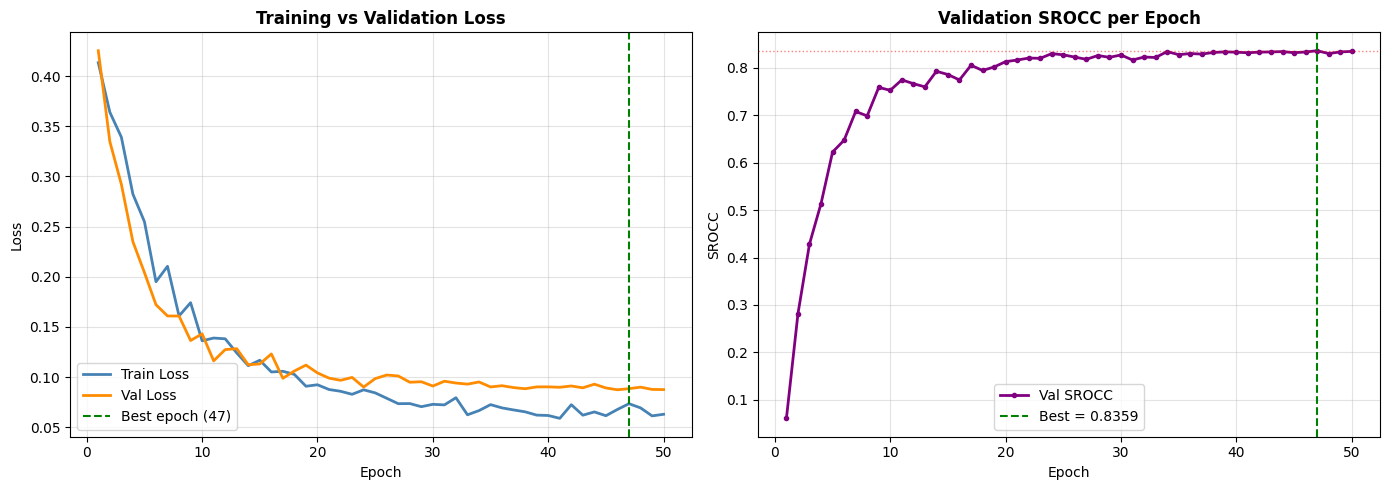

Curves saved to /kaggle/working/outputs/curves_v5.png


In [53]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, color='steelblue',  lw=2, label='Train Loss')
ax1.plot(epochs, val_losses,   color='darkorange', lw=2, label='Val Loss')
ax1.axvline(
    x=best_epoch, color='green', linestyle='--', lw=1.5,
    label=f'Best epoch ({best_epoch})'
)
ax1.set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.35)

ax2.plot(
    epochs, val_sroccs, color='purple', lw=2,
    marker='o', markersize=3, label='Val SROCC'
)
ax2.axvline(
    x=best_epoch, color='green', linestyle='--', lw=1.5,
    label=f'Best = {max(val_sroccs):.4f}'
)
ax2.axhline(y=max(val_sroccs), color='red', linestyle=':', lw=1, alpha=0.5)
ax2.set_title('Validation SROCC per Epoch', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('SROCC')
ax2.legend()
ax2.grid(True, alpha=0.35)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'curves_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Curves saved to {save_path}')

## Cell 12 - Evaluation with Test-Time Augmentation

In [54]:
def get_predictions_standard(model, loader):
    """
    Single-pass inference on the test set.
    Returns predictions and targets in the original 0-100 MOS scale.
    """
    model.eval()
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())

    return denorm_mos(np.array(all_preds)), denorm_mos(np.array(all_targets))


def get_predictions_tta(model, root, json_path, test_idx, n_runs=5):
    """
    Test-Time Augmentation inference.

    Runs n_runs forward passes on each test image with different
    random augmentations. Averaging the predictions reduces per-image
    variance and consistently improves SROCC, PLCC, and KROCC.
    Returns averaged predictions and targets in the 0-100 scale.
    """
    model.eval()
    all_run_preds = []
    all_targets   = None

    for run in range(n_runs):
        tta_ds     = SAUDDataset(root, json_path, transform=tta_transform)
        tta_loader = DataLoader(
            Subset(tta_ds, test_idx),
            batch_size=BATCH_SIZE, shuffle=False,
            num_workers=2, pin_memory=True
        )

        run_preds   = []
        run_targets = []
        with torch.no_grad():
            for imgs, labels in tta_loader:
                preds = model(imgs.to(DEVICE)).cpu().numpy()
                run_preds.extend(preds)
                run_targets.extend(labels.numpy())

        all_run_preds.append(np.array(run_preds))
        if all_targets is None:
            all_targets = np.array(run_targets)

        print(f'  TTA run {run+1}/{n_runs} done')

    avg_preds = np.mean(all_run_preds, axis=0)
    return denorm_mos(avg_preds), denorm_mos(all_targets)


def compute_metrics(preds, targets):
    """
    Computes the four standard IQA evaluation metrics.
    All inputs must be in the original 0-100 MOS scale.
    """
    srocc, _ = spearmanr(preds,  targets)
    plcc,  _ = pearsonr(preds,   targets)
    krocc, _ = kendalltau(preds, targets)
    rmse     = np.sqrt(np.mean((preds - targets) ** 2))
    return {
        'SROCC': float(srocc),
        'PLCC' : float(plcc),
        'KROCC': float(krocc),
        'RMSE' : float(rmse)
    }


print('Running standard evaluation...')
std_preds,  std_targets  = get_predictions_standard(model, test_loader)
std_metrics = compute_metrics(std_preds, std_targets)

print('\nRunning TTA evaluation...')
tta_preds,  tta_targets  = get_predictions_tta(
    model, DATASET_ROOT, JSON_PATH, test_indices, n_runs=TTA_RUNS
)
tta_metrics = compute_metrics(tta_preds, tta_targets)

print()
print('='*58)
print('  TEST SET RESULTS')
print('='*58)
print(f"  {'Metric':<10} {'Standard':>12} {'With TTA':>12} {'Gain':>8}")
print('  ' + '-'*44)
for k in ['SROCC', 'PLCC', 'KROCC', 'RMSE']:
    s    = std_metrics[k]
    t    = tta_metrics[k]
    gain = (t - s) if k != 'RMSE' else (s - t)
    sign = '+' if gain > 0 else ''
    print(f"  {k:<10} {s:>12.4f} {t:>12.4f} {sign}{gain:>7.4f}")
print('='*58)

final_preds   = tta_preds
final_targets = tta_targets
metrics       = tta_metrics

Running standard evaluation...

Running TTA evaluation...
Loaded  : 1000 samples
MOS     : [0, 88] original scale
  TTA run 1/5 done
Loaded  : 1000 samples
MOS     : [0, 88] original scale
  TTA run 2/5 done
Loaded  : 1000 samples
MOS     : [0, 88] original scale
  TTA run 3/5 done
Loaded  : 1000 samples
MOS     : [0, 88] original scale
  TTA run 4/5 done
Loaded  : 1000 samples
MOS     : [0, 88] original scale
  TTA run 5/5 done

  TEST SET RESULTS
  Metric         Standard     With TTA     Gain
  --------------------------------------------
  SROCC            0.8239       0.8305 + 0.0066
  PLCC             0.8317       0.8410 + 0.0093
  KROCC            0.6398       0.6488 + 0.0090
  RMSE            12.3802      12.0436 + 0.3366


## Cell 13 - Scatter Plots

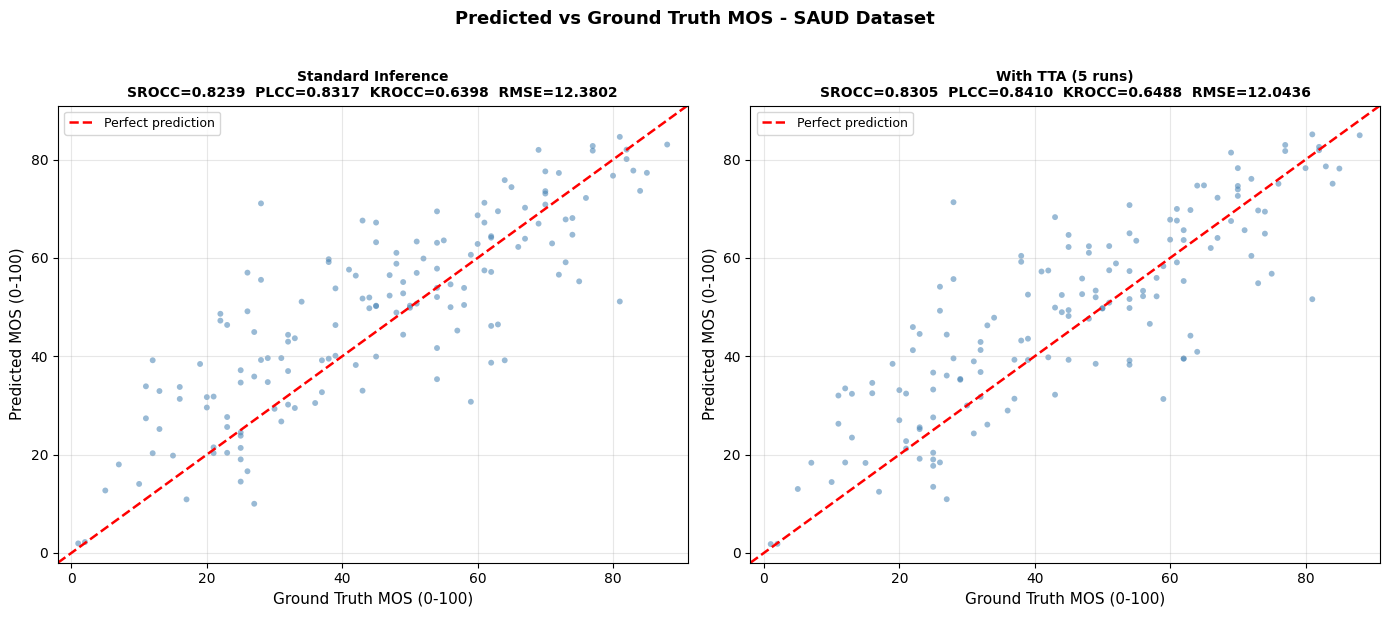

Scatter plot saved to /kaggle/working/outputs/scatter_v5.png


In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_data = [
    (ax1, std_preds,   std_targets,  std_metrics,  'Standard Inference'),
    (ax2, final_preds, final_targets, metrics, f'With TTA ({TTA_RUNS} runs)')
]

for ax, preds, targets, m, label in plot_data:
    ax.scatter(
        targets, preds, alpha=0.55, s=18,
        color='steelblue', edgecolors='none'
    )
    lo = min(targets.min(), preds.min()) - 3
    hi = max(targets.max(), preds.max()) + 3
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.8, label='Perfect prediction')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Ground Truth MOS (0-100)', fontsize=11)
    ax.set_ylabel('Predicted MOS (0-100)',    fontsize=11)
    title = (
        f"{label}\n"
        f"SROCC={m['SROCC']:.4f}  PLCC={m['PLCC']:.4f}  "
        f"KROCC={m['KROCC']:.4f}  RMSE={m['RMSE']:.4f}"
    )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Predicted vs Ground Truth MOS - SAUD Dataset',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'scatter_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Scatter plot saved to {save_path}')

## Cell 13b - Residuals Histogram (Predicted - True)

Residual stats (TTA predictions):
  Mean   : +3.4502  (0 = no bias)
  Std    : 11.5388   (spread of errors)
  MAE    : 9.2944   (average absolute error in 0-100 scale)


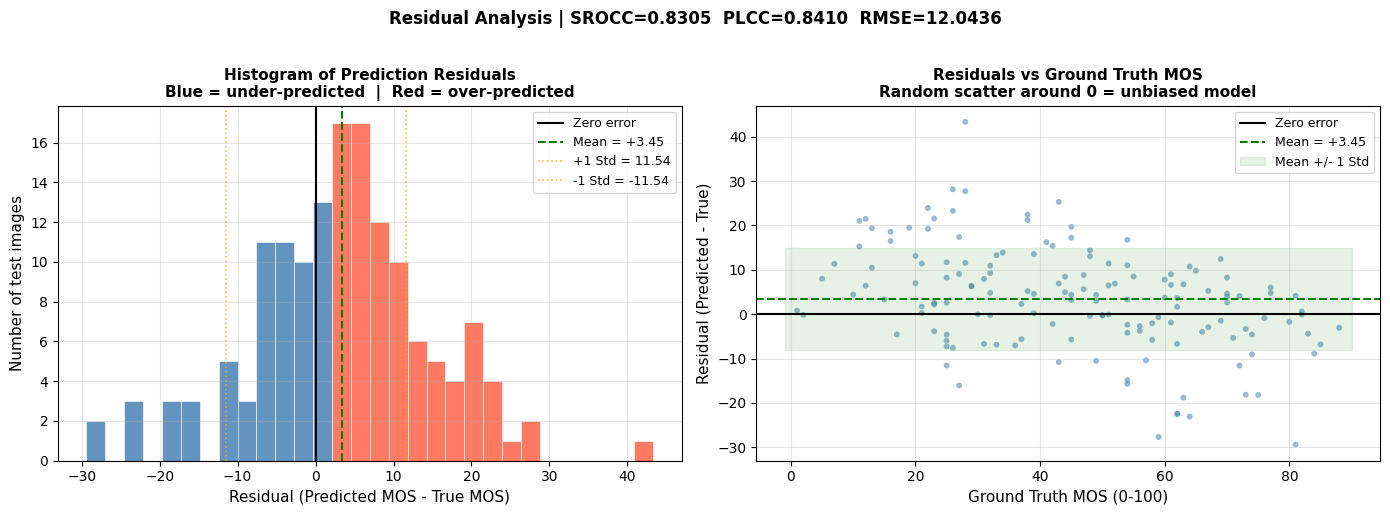

Residuals histogram saved to /kaggle/working/outputs/residuals_v5.png


In [57]:
# Residuals = predicted MOS - ground truth MOS
# Computed on TTA predictions (final_preds, final_targets)
# A residual close to 0 means the model predicted correctly.
# Positive residual = model over-predicted quality.
# Negative residual = model under-predicted quality.

residuals = final_preds - final_targets

mean_res  = float(np.mean(residuals))
std_res   = float(np.std(residuals))
mae_res   = float(np.mean(np.abs(residuals)))

print(f'Residual stats (TTA predictions):')
print(f'  Mean   : {mean_res:+.4f}  (0 = no bias)')
print(f'  Std    : {std_res:.4f}   (spread of errors)')
print(f'  MAE    : {mae_res:.4f}   (average absolute error in 0-100 scale)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of residuals
ax = axes[0]
n_bins = 30
counts, bin_edges, patches = ax.hist(
    residuals, bins=n_bins,
    color='steelblue', edgecolor='white', linewidth=0.5,
    alpha=0.85
)
# Color bars by sign: positive = over-prediction, negative = under-prediction
for patch, left_edge in zip(patches, bin_edges[:-1]):
    if left_edge >= 0:
        patch.set_facecolor('tomato')
    else:
        patch.set_facecolor('steelblue')

ax.axvline(x=0,        color='black',  linestyle='-',  lw=1.5, label='Zero error')
ax.axvline(x=mean_res, color='green',  linestyle='--', lw=1.5, label=f'Mean = {mean_res:+.2f}')
ax.axvline(x= std_res, color='orange', linestyle=':',  lw=1.2, label=f'+1 Std = {std_res:.2f}',  alpha=0.8)
ax.axvline(x=-std_res, color='orange', linestyle=':',  lw=1.2, label=f'-1 Std = {-std_res:.2f}', alpha=0.8)

ax.set_xlabel('Residual (Predicted MOS - True MOS)', fontsize=11)
ax.set_ylabel('Number of test images',               fontsize=11)
ax.set_title(
    'Histogram of Prediction Residuals\n'
    'Blue = under-predicted  |  Red = over-predicted',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: residuals vs ground truth (shows if error is systematic)
ax2 = axes[1]
ax2.scatter(
    final_targets, residuals,
    alpha=0.55, s=18, color='steelblue', edgecolors='none'
)
ax2.axhline(y=0,        color='black', linestyle='-',  lw=1.5, label='Zero error')
ax2.axhline(y=mean_res, color='green', linestyle='--', lw=1.5, label=f'Mean = {mean_res:+.2f}')
ax2.fill_between(
    [final_targets.min()-2, final_targets.max()+2],
    mean_res - std_res, mean_res + std_res,
    alpha=0.1, color='green', label=f'Mean +/- 1 Std'
)
ax2.set_xlabel('Ground Truth MOS (0-100)', fontsize=11)
ax2.set_ylabel('Residual (Predicted - True)', fontsize=11)
ax2.set_title(
    'Residuals vs Ground Truth MOS\n'
    'Random scatter around 0 = unbiased model',
    fontsize=11, fontweight='bold'
)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'Residual Analysis | SROCC={metrics["SROCC"]:.4f}  PLCC={metrics["PLCC"]:.4f}  RMSE={metrics["RMSE"]:.4f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'residuals_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Residuals histogram saved to {save_path}')


## Cell 14 - Save Results

In [60]:
import shutil

results = {
    'version'          : 'V5 - Multi-Stage Concatenation Fusion',
    'backbone'         : 'swin_base_patch4_window7_224',
    'fusion'           : 'Concatenation of Stage 2, Stage 3, Stage 4 GAP features',
    'frozen'           : ['patch_embed', 'stage1'],
    'trainable'        : ['stage2', 'stage3', 'stage4', 'regression_mlp'],
    'stage_channels'   : model.stage_channels,
    'fused_dim'        : model.fused_dim,
    'loss'             : f'{W_L1}*L1 + {W_MSE}*MSE + {W_PLCC}*(1-PLCC) + {W_RANK}*Rank',
    'lr_backbone'      : LR_BACKBONE,
    'lr_head'          : LR_HEAD,
    'tta_runs'         : TTA_RUNS,
    'best_epoch'       : best_epoch,
    'best_val_srocc'   : round(best_val_srocc, 4),
    'standard_metrics' : {k: round(v, 4) for k, v in std_metrics.items()},
    'tta_metrics'      : {k: round(v, 4) for k, v in tta_metrics.items()}
}

results_path = os.path.join(OUTPUT_DIR, 'results_v5.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

# Copy all outputs to /kaggle/working so they appear in the Output tab.
for fname in os.listdir(OUTPUT_DIR):
    shutil.copy(
        os.path.join(OUTPUT_DIR, fname),
        os.path.join('/kaggle/working', fname)
    )

print('='*55)
print('  FINAL SUMMARY - V5')
print('='*55)
print(f'Backbone      : Swin-Base (ImageNet pretrained)')
print(f'Fusion        : Concatenation [Stage2 || Stage3 || Stage4]')
print(f'Fused dim     : {model.fused_dim}')
print(f'Frozen        : patch_embed + Stage 1')
print(f'Trainable     : Stage 2 + Stage 3 + Stage 4 + Head')
print(f'Loss          : L1 + MSE + PLCC + RankLoss')
print(f'Best epoch    : {best_epoch} / {len(train_losses)}')
print(f'Val SROCC     : {best_val_srocc:.4f}')
print()
print(f"  {'Metric':<10} {'Standard':>12} {'TTA':>12}")
print('  ' + '-'*36)
for k in ['SROCC', 'PLCC', 'KROCC', 'RMSE']:
    print(f"  {k:<10} {std_metrics[k]:>12.4f} {tta_metrics[k]:>12.4f}")
print('='*55)
print('\nAll files saved. Download from the Output tab.')

  FINAL SUMMARY - V5
Backbone      : Swin-Base (ImageNet pretrained)
Fusion        : Concatenation [Stage2 || Stage3 || Stage4]
Fused dim     : 1792
Frozen        : patch_embed + Stage 1
Trainable     : Stage 2 + Stage 3 + Stage 4 + Head
Loss          : L1 + MSE + PLCC + RankLoss
Best epoch    : 47 / 50
Val SROCC     : 0.8359

  Metric         Standard          TTA
  ------------------------------------
  SROCC            0.8239       0.8305
  PLCC             0.8317       0.8410
  KROCC            0.6398       0.6488
  RMSE            12.3802      12.0436

All files saved. Download from the Output tab.
